In [2]:
import os, sys, json, joblib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import torch
warnings.filterwarnings('ignore')

PROJECT_ROOT = 'C:/Users/BeratErcan/Home-Credit-Default-Risk'
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

from src.config import PROCESSED_DIR, MODEL_DIR
from src.preprocessing import get_tree_data, load_data, add_features, NEW_FEATURES, CreditRiskANN
from src.train_lr_svm import get_lr_svm_data
from sklearn.metrics import roc_auc_score

# ── Dark Theme ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "#0D1117",
    "axes.facecolor": "#0D1117",
    "axes.edgecolor": "#1E2A3A",
    "axes.labelcolor": "#C9D1D9",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "text.color": "#C9D1D9",
    "xtick.color": "#8B949E",
    "ytick.color": "#8B949E",
    "grid.color": "#1E2A3A",
    "grid.linestyle": "--",
    "grid.alpha": 0.5,
    "font.size": 11,
    "savefig.facecolor": "#0D1117",
})

PALETTE      = {0: "#00F5FF", 1: "#ff2d3b"}
CYAN         = "#00F5FF"
RED          = "#ff2d3b"
ORANGE       = "#FFA500"
PURPLE       = "#B370F5"
GREEN        = "#39D353"
MODELS_COLOR = {
    'XGBoost':            RED,
    'ANN':                ORANGE,
    'LogisticRegression': CYAN,
    'SVM':                PURPLE,
}

# ── Load data ──────────────────────────────────────────────────────────────────
df_raw, feature_sets = load_data()
df = add_features(df_raw.copy())
for col in NEW_FEATURES:
    df[col] = df[col].fillna(df[col].median() if col in
              ['EXT_SOURCES_MEAN','EXT_SOURCES_STD','EXT_SOURCES_MIN'] else 0)

df_model = pd.read_parquet(f'{PROCESSED_DIR}df_model.parquet')
print(f"df_raw:   {df_raw.shape}")
print(f"df_model: {df_model.shape}")

# ── Load models ────────────────────────────────────────────────────────────────
xgb_model  = joblib.load(f'{MODEL_DIR}xgboost.joblib')
lr_bundle  = joblib.load(f'{MODEL_DIR}logistic_regression.joblib')
ann_bundle = joblib.load(f'{MODEL_DIR}ann.joblib')
svm_bundle = joblib.load(f'{MODEL_DIR}svm.joblib')
print("All models loaded.")

# ── Train/test splits ──────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test, scale_pos_weight = get_tree_data()
(X_train_lr, X_test_lr, y_train_lr, y_test_lr, scaler_lr,
 X_train_svm, X_test_svm, y_train_svm, scaler_svm) = get_lr_svm_data()

# ── Predictions ────────────────────────────────────────────────────────────────
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_prob_lr  = lr_bundle['model'].predict_proba(X_test_lr)[:, 1]
y_prob_svm = svm_bundle['model'].predict_proba(X_test_svm)[:, 1]

ann_bundle['model'].eval()
with torch.no_grad():
    y_prob_ann = ann_bundle['model'](
        torch.FloatTensor(ann_bundle['scaler'].transform(X_test))
    ).squeeze().numpy()

predictions = {
    'XGBoost':            y_prob_xgb,
    'ANN':                y_prob_ann,
    'LogisticRegression': y_prob_lr,
    'SVM':                y_prob_svm,
}

print("\nPredictions:")
for name, prob in predictions.items():
    print(f"  {name:20s} AUC={roc_auc_score(y_test, prob):.4f}")

# ── SHAP ───────────────────────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
print(f"\nSHAP values: {shap_values.shape}")


df_raw:   (307511, 109)
df_model: (307511, 109)
All models loaded.
Train: (246008, 114) | Test: (61503, 114)
Train default rate: 0.0807
Test default rate:  0.0807
scale_pos_weight: 11.39
Total features: 114
Train: (246008, 84) | Test: (61503, 84)
Train default rate: 0.0807
Test default rate:  0.0807
Train: (246008, 101) | Test: (61503, 101)
Train default rate: 0.0807
Test default rate:  0.0807
LR  — train: (293992, 84),  features: 84
SVM — train: (293992, 101), features: 101
After SMOTE — default rate: 0.2308

Predictions:
  XGBoost              AUC=0.7866
  ANN                  AUC=0.7623
  LogisticRegression   AUC=0.7609
  SVM                  AUC=0.7603

SHAP values: (61503, 114)


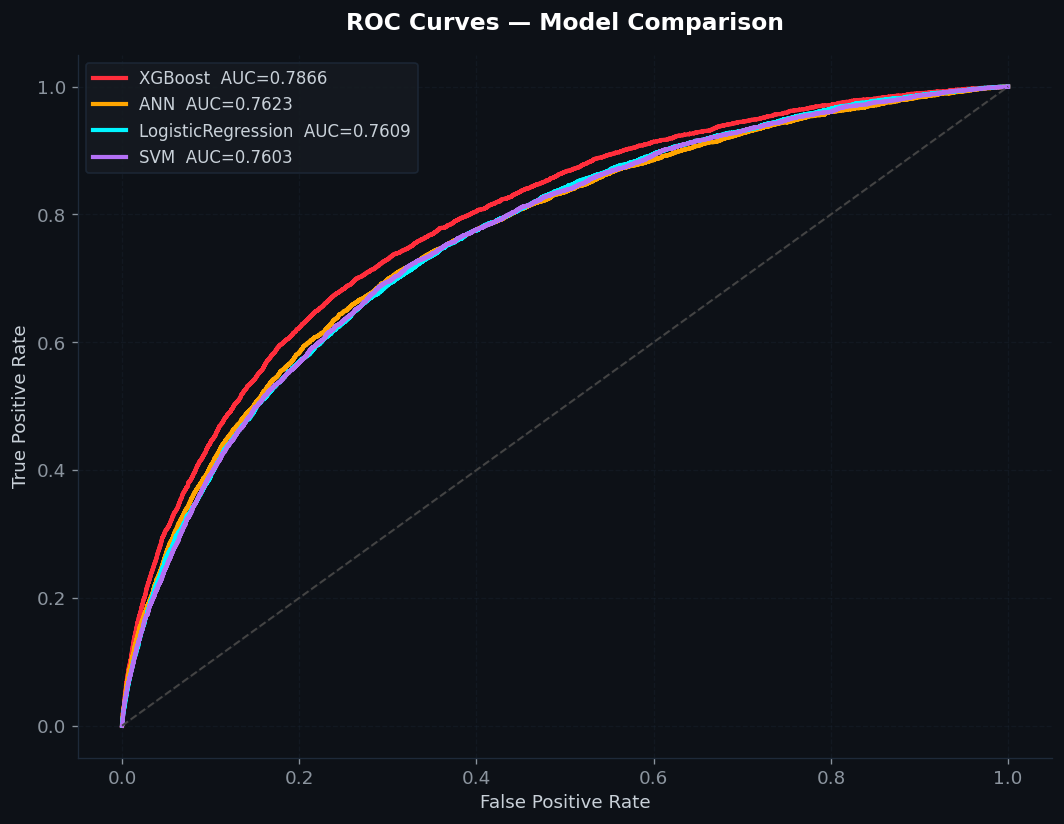

In [3]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(9, 7))
ax.set_facecolor('#0D1117')

for name, prob in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, color=MODELS_COLOR[name], lw=2.5,
            label=f'{name}  AUC={auc:.4f}')

ax.plot([0,1],[0,1], color='#444444', lw=1.2, linestyle='--')
ax.fill_between([0,1],[0,1],[0,1], alpha=0.03, color='white')
ax.set_xlabel('False Positive Rate', color='#C9D1D9')
ax.set_ylabel('True Positive Rate', color='#C9D1D9')
ax.set_title('ROC Curves — Model Comparison', color='white', fontsize=14, fontweight='bold', pad=15)
ax.legend(facecolor='#161B22', edgecolor='#1E2A3A', labelcolor='#C9D1D9', fontsize=10)
ax.grid(True, alpha=0.3, color='#1E2A3A')
plt.tight_layout()
plt.savefig('reports/roc_curves.png', dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()

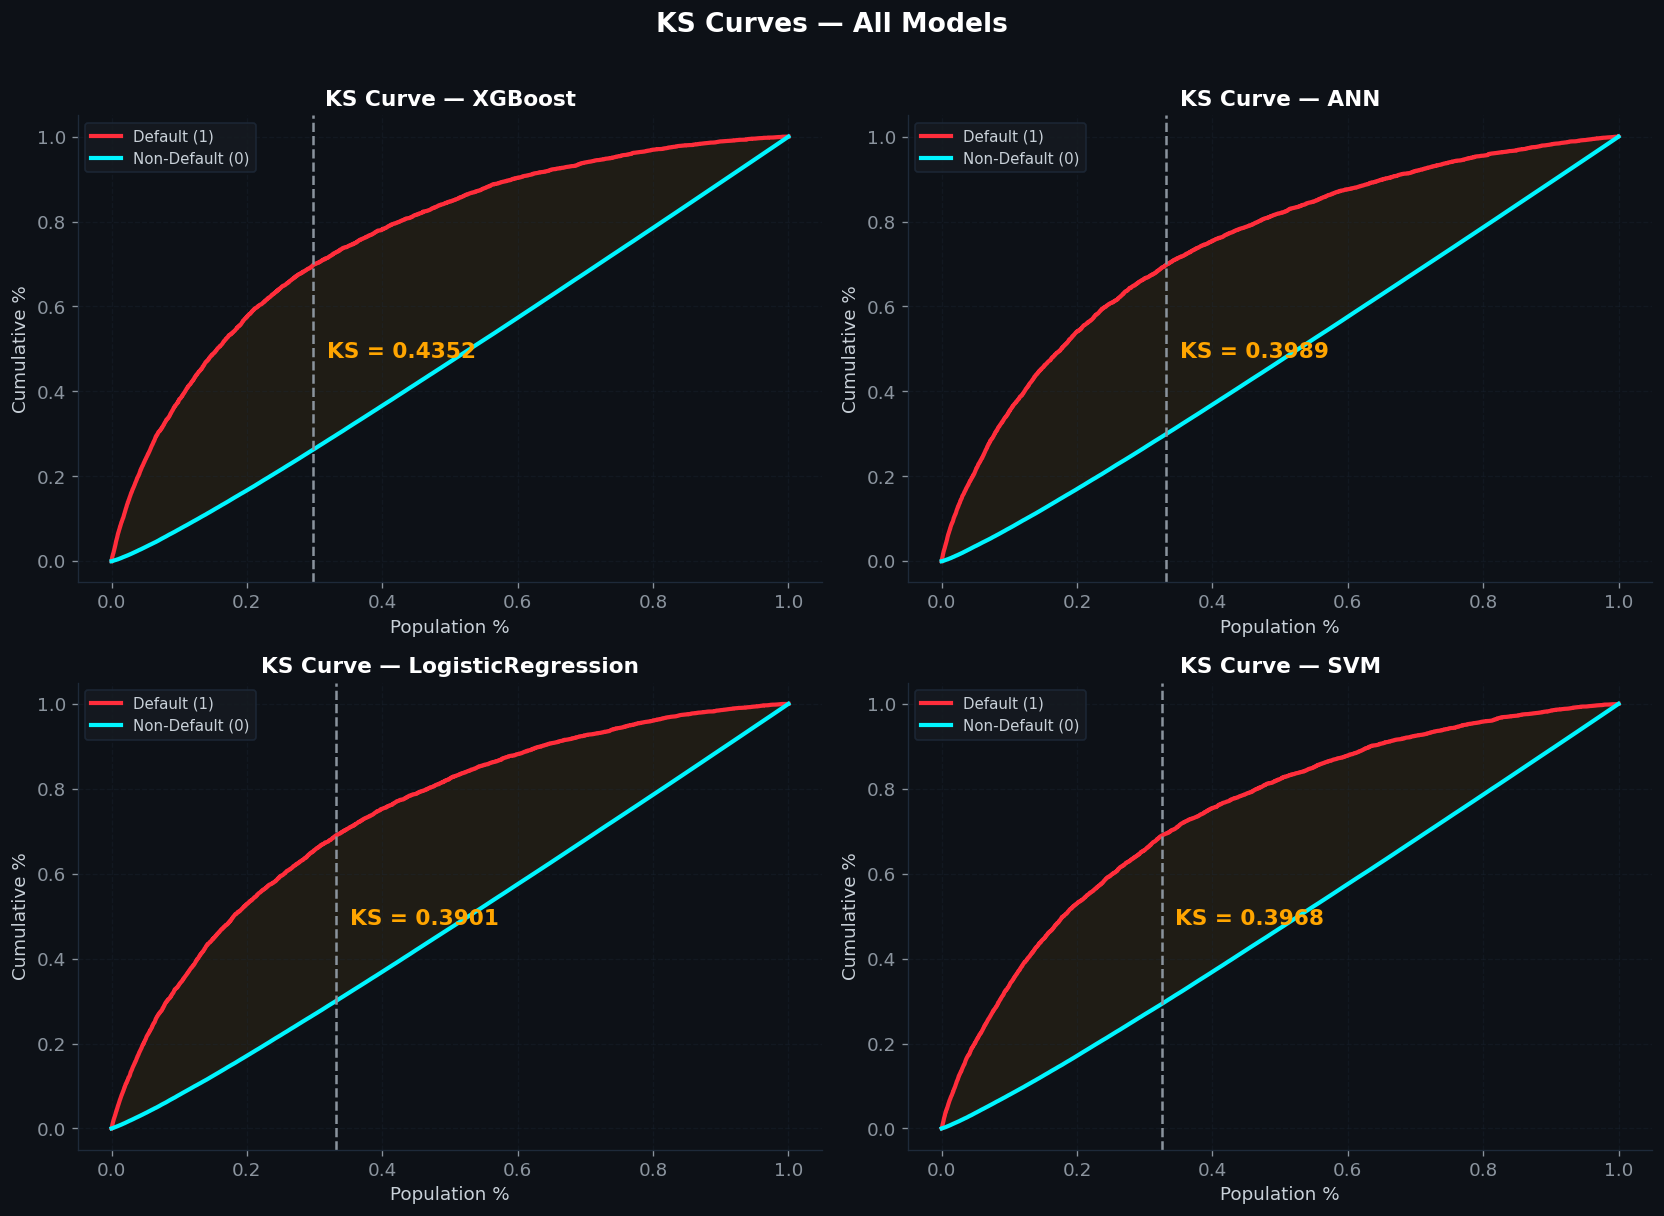

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor='#0D1117')
axes = axes.flatten()

for ax, (name, prob) in zip(axes, predictions.items()):
    ax.set_facecolor('#0D1117')
    df_ks = pd.DataFrame({'y': y_test.values, 'prob': prob})
    df_ks = df_ks.sort_values('prob', ascending=False).reset_index(drop=True)
    df_ks['cum_pos'] = (df_ks['y']==1).cumsum() / (df_ks['y']==1).sum()
    df_ks['cum_neg'] = (df_ks['y']==0).cumsum() / (df_ks['y']==0).sum()
    ks_val = (df_ks['cum_pos'] - df_ks['cum_neg']).abs().max()
    ks_idx = (df_ks['cum_pos'] - df_ks['cum_neg']).abs().idxmax()

    x = np.linspace(0, 1, len(df_ks))
    ax.plot(x, df_ks['cum_pos'].values, color=RED,  lw=2.5, label='Default (1)')
    ax.plot(x, df_ks['cum_neg'].values, color=CYAN, lw=2.5, label='Non-Default (0)')
    ax.fill_between(x, df_ks['cum_pos'].values, df_ks['cum_neg'].values,
                    alpha=0.08, color=ORANGE)
    ax.axvline(x=ks_idx/len(df_ks), color='#8B949E', linestyle='--', lw=1.5)
    ax.annotate(f'KS = {ks_val:.4f}',
                xy=(ks_idx/len(df_ks)+0.02, 0.48),
                fontsize=13, fontweight='bold',
                color=ORANGE)
    ax.set_title(f'KS Curve — {name}', color='white', fontweight='bold')
    ax.set_xlabel('Population %', color='#C9D1D9')
    ax.set_ylabel('Cumulative %', color='#C9D1D9')
    ax.legend(facecolor='#161B22', edgecolor='#1E2A3A', labelcolor='#C9D1D9', fontsize=9)
    ax.grid(True, alpha=0.3, color='#1E2A3A')
    ax.tick_params(colors='#8B949E')
    for spine in ax.spines.values():
        spine.set_edgecolor('#1E2A3A')

plt.suptitle('KS Curves — All Models', color='white', fontsize=16,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('reports/ks_curves_all.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()


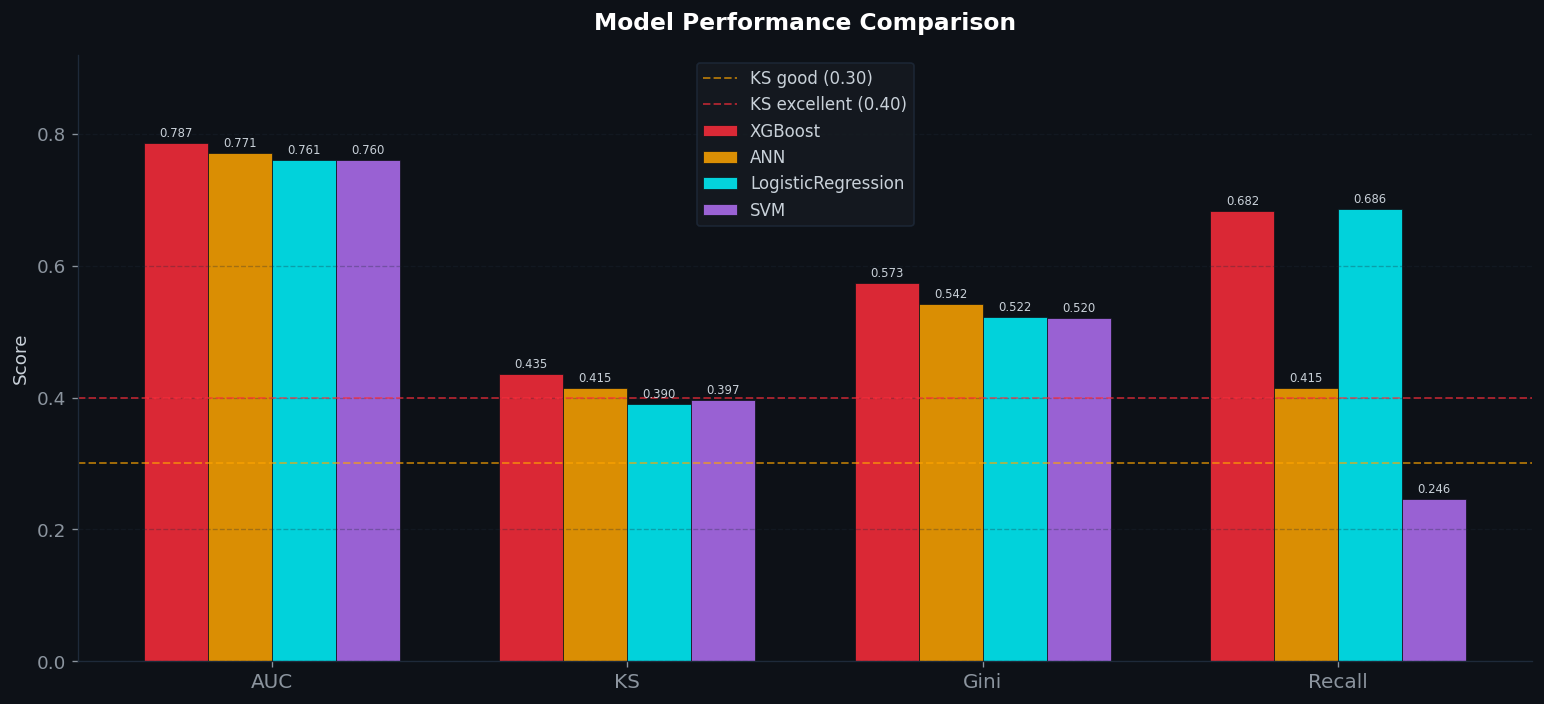

In [5]:
results = {
    'XGBoost':            {'AUC': 0.7866, 'KS': 0.4352, 'Gini': 0.5732, 'Recall': 0.6824},
    'ANN':                {'AUC': 0.7712, 'KS': 0.4149, 'Gini': 0.5424, 'Recall': 0.4149},
    'LogisticRegression': {'AUC': 0.7609, 'KS': 0.3901, 'Gini': 0.5218, 'Recall': 0.6860},
    'SVM':                {'AUC': 0.7603, 'KS': 0.3968, 'Gini': 0.5205, 'Recall': 0.2465},
}
metrics = ['AUC', 'KS', 'Gini', 'Recall']
x       = np.arange(len(metrics))
width   = 0.18

fig, ax = plt.subplots(figsize=(13, 6), facecolor='#0D1117')
ax.set_facecolor('#0D1117')

for i, (model, vals) in enumerate(results.items()):
    bars = ax.bar(x + i*width, [vals[m] for m in metrics],
                  width, label=model,
                  color=MODELS_COLOR[model], alpha=0.85,
                  edgecolor='#0D1117', linewidth=0.5)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom',
                fontsize=7, color='#C9D1D9')

ax.axhline(0.30, color='#FFA500', linestyle='--', lw=1.2, alpha=0.6, label='KS good (0.30)')
ax.axhline(0.40, color='#ff2d3b', linestyle='--', lw=1.2, alpha=0.6, label='KS excellent (0.40)')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(metrics, fontsize=12, color='#C9D1D9')
ax.set_ylabel('Score', color='#C9D1D9')
ax.set_ylim(0, 0.92)
ax.set_title('Model Performance Comparison', color='white',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(facecolor='#161B22', edgecolor='#1E2A3A',
          labelcolor='#C9D1D9', fontsize=10)
ax.grid(True, axis='y', alpha=0.3, color='#1E2A3A')
ax.tick_params(colors='#8B949E')
for spine in ax.spines.values():
    spine.set_edgecolor('#1E2A3A')

plt.tight_layout()
plt.savefig('reports/model_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()

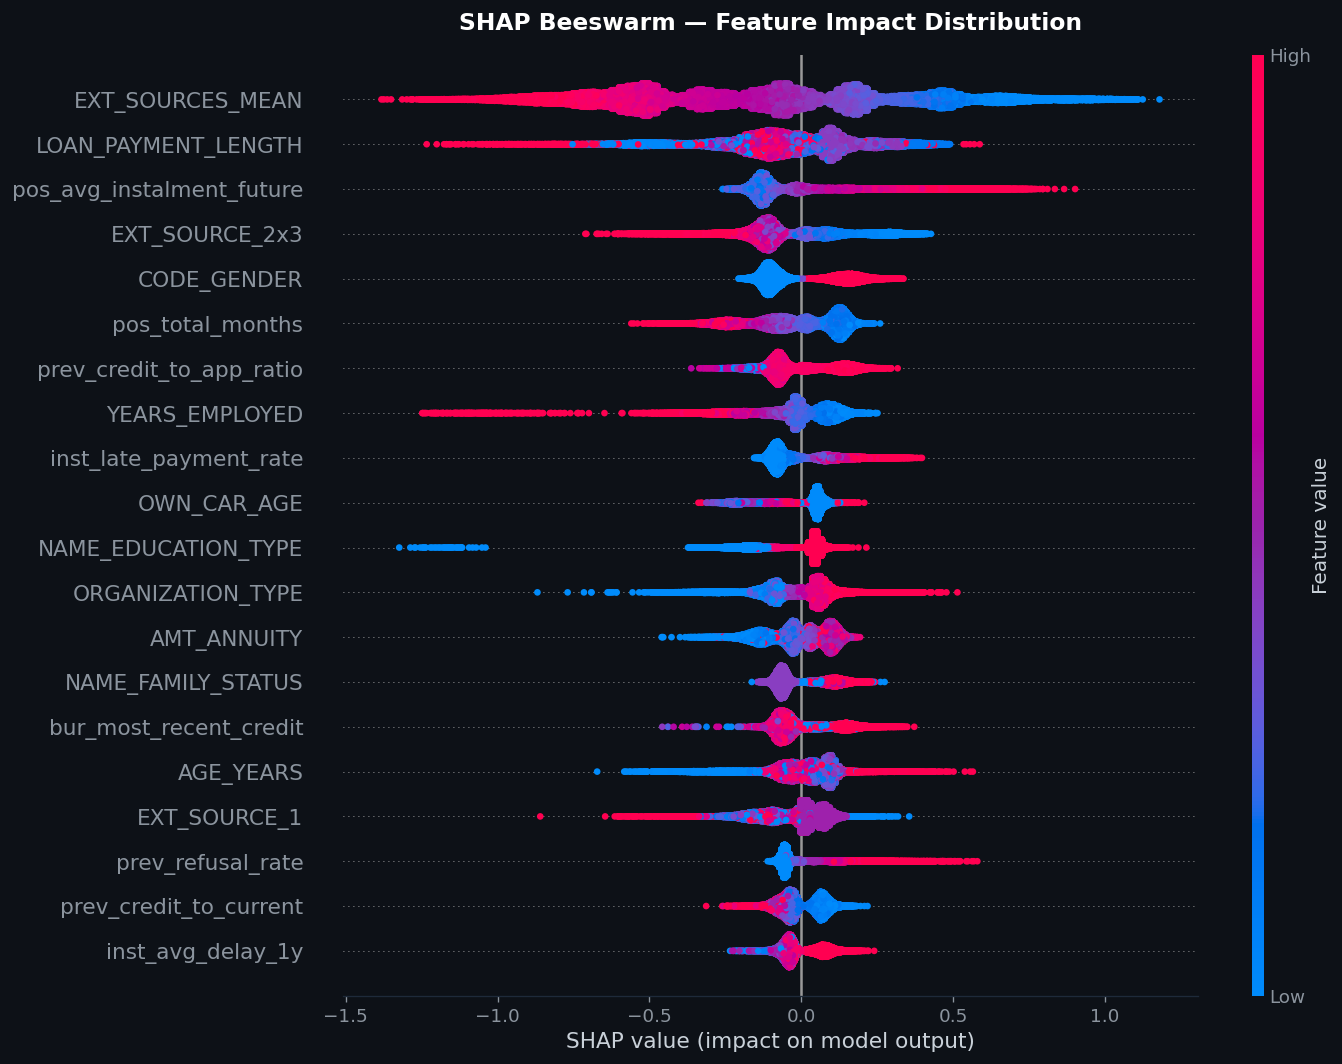

In [6]:
# SHAP has its own plot engine so we patch colors manually
plt.figure(figsize=(12, 9), facecolor='#0D1117')
ax = plt.gca()
ax.set_facecolor('#0D1117')

shap.summary_plot(
    shap_values, X_test,
    max_display=20,
    show=False,
    color_bar=True,
    plot_size=None,
)

plt.gcf().set_facecolor('#0D1117')
for ax in plt.gcf().axes:
    ax.set_facecolor('#0D1117')
    ax.tick_params(colors='#8B949E')
    ax.xaxis.label.set_color('#C9D1D9')
    ax.yaxis.label.set_color('#C9D1D9')
    for spine in ax.spines.values():
        spine.set_edgecolor('#1E2A3A')

plt.title('SHAP Beeswarm — Feature Impact Distribution',
          color='white', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('reports/shap/shap_beeswarm.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()

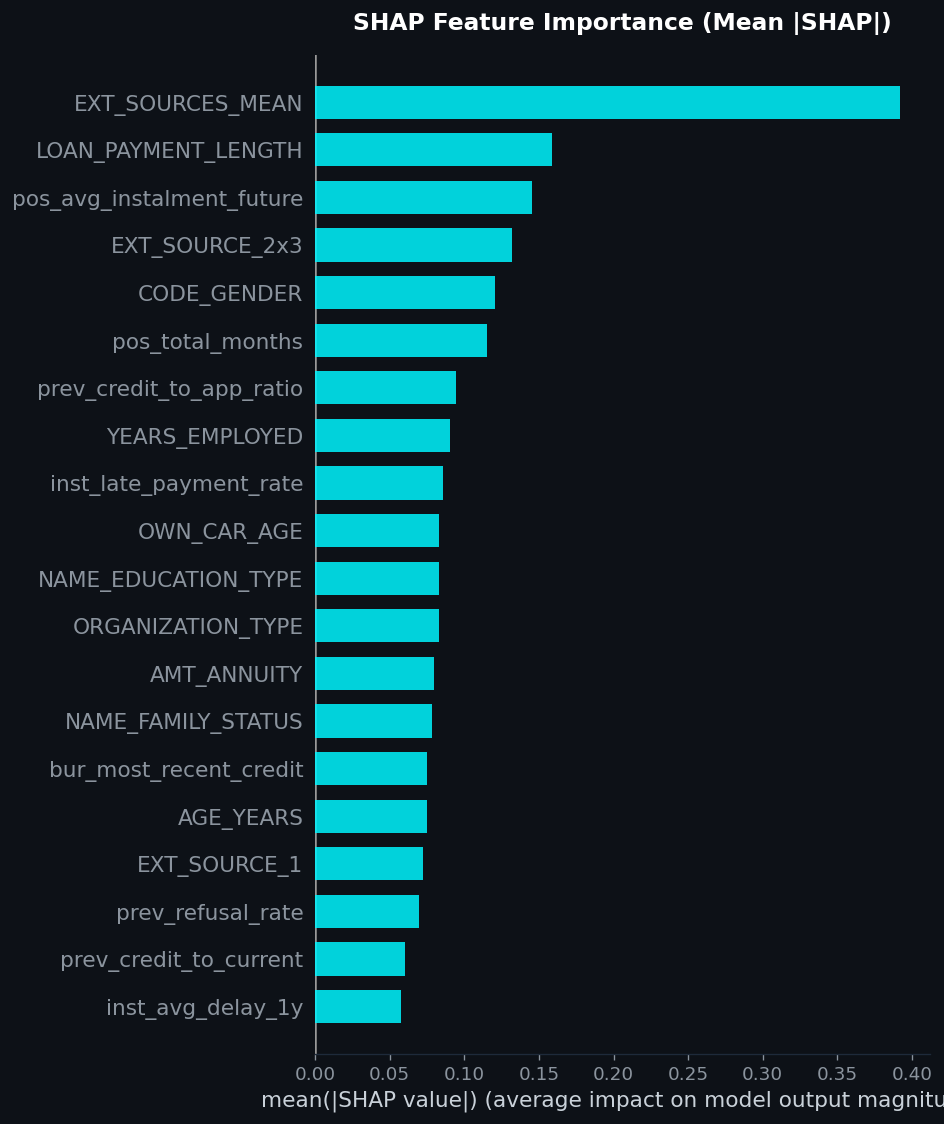

In [7]:
plt.figure(figsize=(10, 8), facecolor='#0D1117')

shap.summary_plot(
    shap_values, X_test,
    plot_type='bar',
    max_display=20,
    show=False,
    color=CYAN,
)

plt.gcf().set_facecolor('#0D1117')
for ax in plt.gcf().axes:
    ax.set_facecolor('#0D1117')
    ax.tick_params(colors='#8B949E')
    ax.xaxis.label.set_color('#C9D1D9')
    ax.yaxis.label.set_color('#C9D1D9')
    for spine in ax.spines.values():
        spine.set_edgecolor('#1E2A3A')
    for patch in ax.patches:
        patch.set_facecolor(CYAN)
        patch.set_alpha(0.85)

plt.title('SHAP Feature Importance (Mean |SHAP|)',
          color='white', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('reports/shap/shap_importance_bar.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()

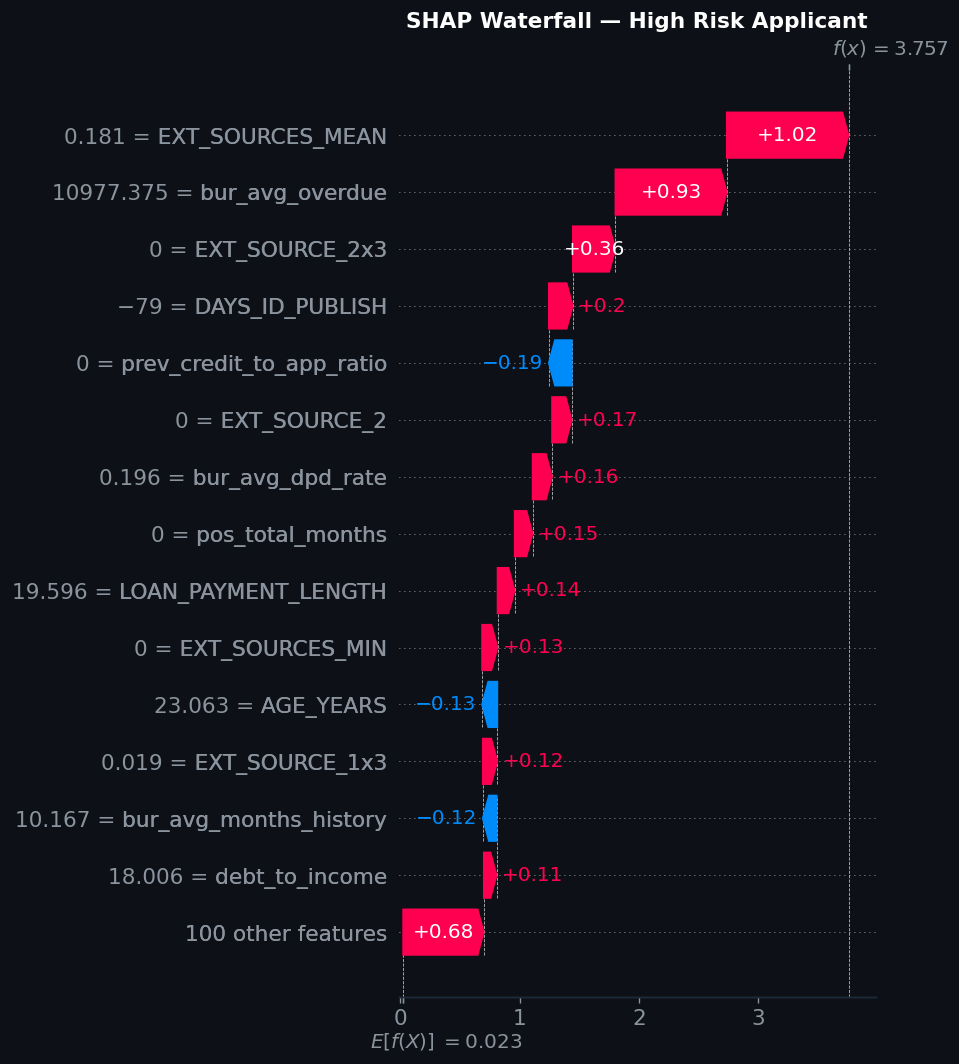

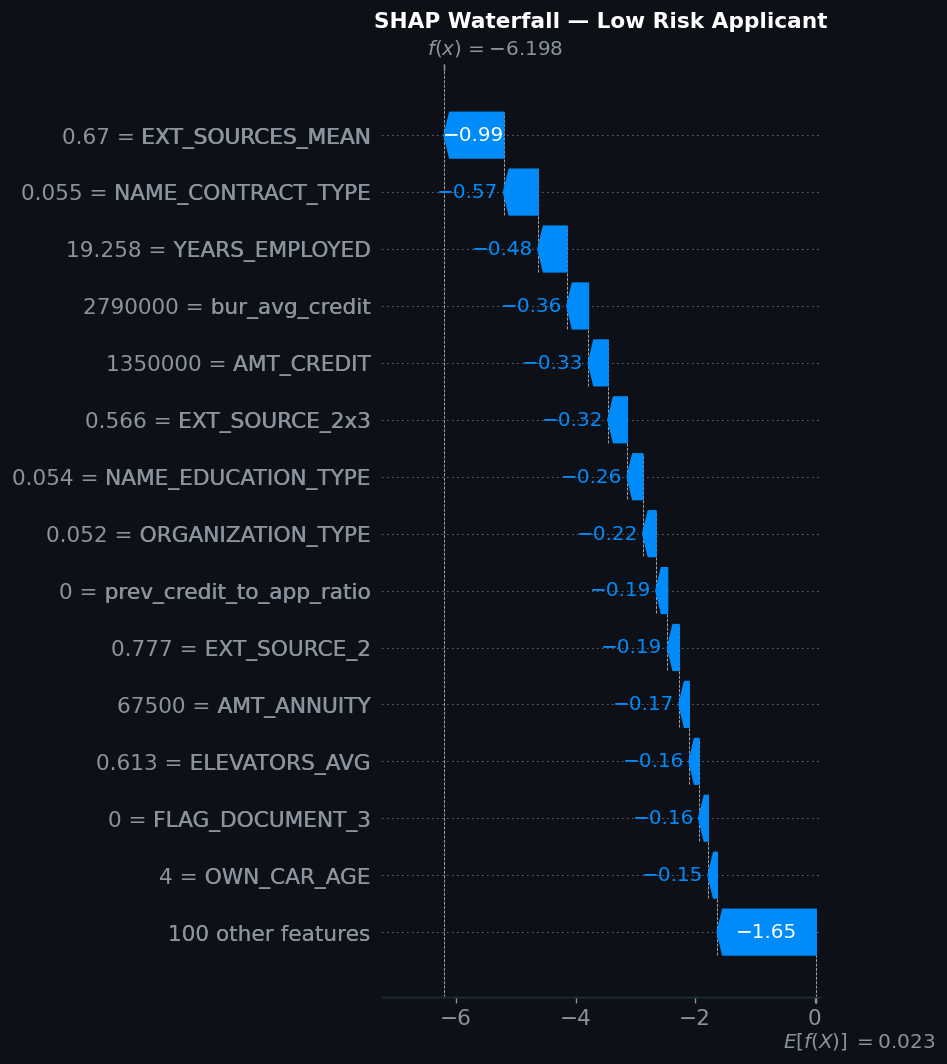

In [8]:
y_prob = y_prob_xgb
default_idx    = np.where(y_test.values == 1)[0]
nondefault_idx = np.where(y_test.values == 0)[0]
high_idx = default_idx[np.argsort(y_prob[default_idx])[-1]]
low_idx  = nondefault_idx[np.argmin(y_prob[nondefault_idx])]

for idx, label, color in [(high_idx, 'High Risk Applicant', RED),
                           (low_idx,  'Low Risk Applicant',  CYAN)]:
    plt.figure(figsize=(14, 6), facecolor='#0D1117')
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[idx],
            base_values=explainer.expected_value,
            data=X_test.iloc[idx],
            feature_names=X_test.columns.tolist()
        ),
        max_display=15, show=False
    )
    plt.gcf().set_facecolor('#0D1117')
    for ax in plt.gcf().axes:
        ax.set_facecolor('#0D1117')
        ax.tick_params(colors='#8B949E')
        for spine in ax.spines.values():
            spine.set_edgecolor('#1E2A3A')
    plt.title(f'SHAP Waterfall — {label}',
              color='white', fontsize=13, fontweight='bold')
    fname = label.lower().replace(' ', '_')
    plt.tight_layout()
    plt.savefig(f'reports/shap/shap_waterfall_{fname}.png',
                dpi=150, bbox_inches='tight', facecolor='#0D1117')
    plt.show()

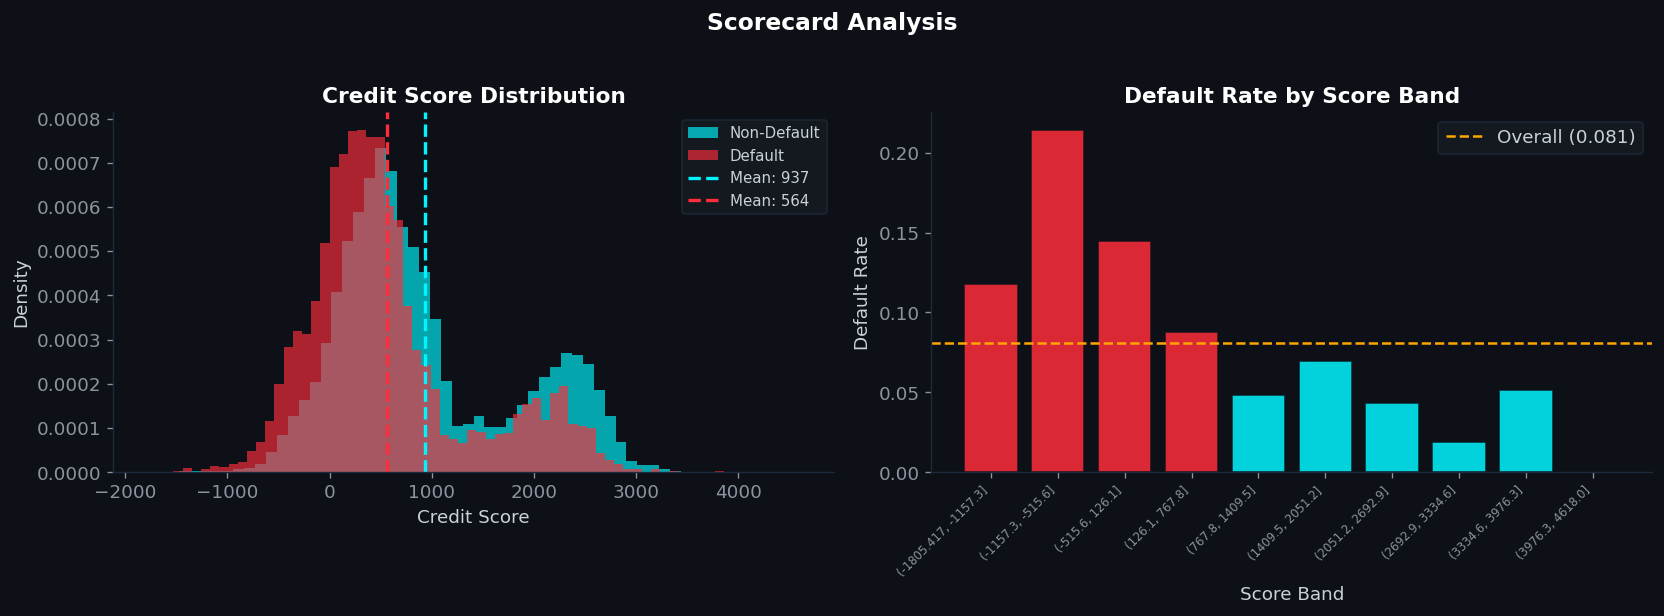

In [9]:
FACTOR   = 20 / np.log(2)
X_lr_s   = lr_bundle['scaler'].transform(X_test_lr)
log_odds = lr_bundle['model'].intercept_[0] + X_lr_s.dot(lr_bundle['model'].coef_[0])
scores   = (-FACTOR * log_odds + 600).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0D1117')
for ax in axes:
    ax.set_facecolor('#0D1117')
    ax.tick_params(colors='#8B949E')
    for spine in ax.spines.values():
        spine.set_edgecolor('#1E2A3A')

# Distribution
axes[0].hist(scores[y_test.values==0], bins=60, alpha=0.65,
             color=CYAN, label='Non-Default', density=True)
axes[0].hist(scores[y_test.values==1], bins=60, alpha=0.65,
             color=RED, label='Default', density=True)
axes[0].axvline(scores[y_test.values==0].mean(), color=CYAN,
                linestyle='--', lw=2,
                label=f'Mean: {scores[y_test.values==0].mean():.0f}')
axes[0].axvline(scores[y_test.values==1].mean(), color=RED,
                linestyle='--', lw=2,
                label=f'Mean: {scores[y_test.values==1].mean():.0f}')
axes[0].set_title('Credit Score Distribution', color='white', fontweight='bold')
axes[0].set_xlabel('Credit Score', color='#C9D1D9')
axes[0].set_ylabel('Density', color='#C9D1D9')
axes[0].legend(facecolor='#161B22', edgecolor='#1E2A3A',
               labelcolor='#C9D1D9', fontsize=9)

# Default rate by band
bands  = pd.cut(pd.Series(scores), bins=10)
df_sc  = pd.DataFrame({'band': bands, 'TARGET': y_test.values})
band_dr = df_sc.groupby('band', observed=True)['TARGET'].mean()
bar_colors = [RED if v > y_test.mean() else CYAN for v in band_dr.values]
axes[1].bar(range(len(band_dr)), band_dr.values,
            color=bar_colors, alpha=0.85, edgecolor='#0D1117')
axes[1].axhline(y_test.mean(), color=ORANGE, linestyle='--',
                lw=1.5, label=f'Overall ({y_test.mean():.3f})')
axes[1].set_xticks(range(len(band_dr)))
axes[1].set_xticklabels([str(b) for b in band_dr.index],
                         rotation=45, ha='right', fontsize=7, color='#8B949E')
axes[1].set_title('Default Rate by Score Band', color='white', fontweight='bold')
axes[1].set_xlabel('Score Band', color='#C9D1D9')
axes[1].set_ylabel('Default Rate', color='#C9D1D9')
axes[1].legend(facecolor='#161B22', edgecolor='#1E2A3A', labelcolor='#C9D1D9')

plt.suptitle('Scorecard Analysis', color='white',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('reports/scorecard/score_distribution.png',
            dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()